# UR5 – Planejamento de Trajetórias
### ENGA73 – Sistemas Robóticos | UFBA 2026/1

**Método:** Polinômio 5º grau




---
## 1. Imports


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time

from ur5_kinematics import (
    fk, fk_com_offset, ik, ik_com_offset,
    JOINT_OFFSET, euler_xyz_to_matrix, rotation_to_rpy, angular_error_deg)
from coppeliasim_zmqremoteapi_client import RemoteAPIClient


---
## 2. Conexão com o CoppeliaSim
> ▶ Simulação deve estar em **Play** antes desta célula.


In [2]:
client = RemoteAPIClient()
sim    = client.getObject('sim')


---
## 3. Handles e Funções Base


In [11]:
joint_handles = []
for i in range(1, 7):
    h = sim.getObject(f'/UR5_joint{i}')
    print(f"  ✅ UR5_joint{i}: handle={h}")
    joint_handles.append(h)

base_handle = sim.getObject('/base')
ee_handle   = sim.getObject('/tcp')

def set_joint_positions(thetas_deg):
    """Envia posições alvo para as 6 juntas (graus)."""
    for handle, angle in zip(joint_handles, thetas_deg):
        sim.setJointTargetPosition(handle, np.radians(angle))

def read_joint_positions():
    """Lê ângulos atuais das 6 juntas em graus."""
    angles = []
    for handle in joint_handles:
        angles.append(np.degrees(sim.getJointPosition(handle)))
    return np.array(angles)

def read_ee_pose():
    """
    Lê posição e orientação do EE relativa à BASE.
    Usa base_handle como referência.
    """
    pos   = sim.getObjectPosition(ee_handle, base_handle)
    euler = sim.getObjectOrientation(ee_handle, base_handle)
    return np.array(pos), np.degrees(euler)

  ✅ UR5_joint1: handle=32
  ✅ UR5_joint2: handle=35
  ✅ UR5_joint3: handle=38
  ✅ UR5_joint4: handle=41
  ✅ UR5_joint5: handle=44
  ✅ UR5_joint6: handle=46


---
## Teoria — Polinômio de quinto grau

O polinômio de 5º grau é determinado resolvendo o sistema linear **Ax = b**:

$$\theta(t) = a_0 + a_1 t + a_2 t^2 + a_3 t^3 + a_4 t^4 + a_5 t^5$$

As 6 condições de contorno (posição, velocidade e aceleração inicial e final) 
determinam univocamente os 6 coeficientes:

$$A = \begin{bmatrix}
1 & t_0 & t_0^2 & t_0^3 & t_0^4 & t_0^5 \\
0 & 1 & 2t_0 & 3t_0^2 & 4t_0^3 & 5t_0^4 \\
0 & 0 & 2 & 6t_0 & 12t_0^2 & 20t_0^3 \\
1 & t_f & t_f^2 & t_f^3 & t_f^4 & t_f^5 \\
0 & 1 & 2t_f & 3t_f^2 & 4t_f^3 & 5t_f^4 \\
0 & 0 & 2 & 6t_f & 12t_f^2 & 20t_f^3
\end{bmatrix}$$

A cada instante $t$, a **velocidade** calculada pelo polinômio é enviada diretamente
para o simulador via `setJointTargetVelocity`.


---
## 5. Implementação da Trajetória Quíntica


In [12]:
def polinomio_quinto_grau(theta_target_deg, duration=None):
    """Move o robô para a configuração alvo usando perfil de velocidade quíntico.
    Parâmetros
    ----------
    theta_target_deg : array (6,)  ângulos alvo em graus
    duration         : float       tempo de movimento [s] (None = automático)
    graph            : bool        plota curvas de posição, vel, acc, jerk

    Retorna
    -------
    tf    : float        duração real do movimento [s]
    error : array (6,)   erro final por junta [graus]
    """
    t0 = 0.0
    v0 = np.zeros(6)
    vf = np.zeros(6)
    a0 = np.zeros(6)
    af = np.zeros(6)

    q0 = np.radians(read_joint_positions())   # posição atual [rad]
    qf = np.radians(theta_target_deg)         # alvo [rad]

    # Duração automática proporcional ao maior deslocamento
    if duration is None:
        duration = np.max(np.abs(qf - q0)) * (4 / (0.5 * np.pi))
        if duration < 1.5:
            duration = 1.5
    tf = t0 + duration

    # Sistema linear Ax = b — coeficientes do polinômio de quinto grau para cada junta
    A = np.array([
        [1, t0, t0**2,  t0**3,   t0**4,   t0**5  ],
        [0,  1, 2*t0,  3*t0**2, 4*t0**3, 5*t0**4 ],
        [0,  0,  2,    6*t0,   12*t0**2, 20*t0**3 ],
        [1, tf, tf**2,  tf**3,   tf**4,   tf**5   ],
        [0,  1, 2*tf,  3*tf**2, 4*tf**3, 5*tf**4  ],
        [0,  0,  2,    6*tf,   12*tf**2, 20*tf**3  ],
    ])
    b = np.column_stack([q0, v0, a0, qf, vf, af])  # shape (6, 6)
    x = [np.linalg.solve(A, b[i]) for i in range(6)]

    # Arrays para gráficos
    pos_arr  = [[] for _ in range(6)]
    vel_arr  = [[] for _ in range(6)]
    acc_arr  = [[] for _ in range(6)]
    jerk_arr = [[] for _ in range(6)]
    time_arr = []



    # ── Logs de erro ─────────────────────────────────────────────────────────
    ee_pos_ref  = []   # posição FK esperada (modelo)
    ee_pos_sim  = []   # posição lida do simulador
    ee_pos_err  = []   # erro de posição [mm]
    ee_ang_err  = []   # erro de orientação [graus]

    # Loop de execução — envia perfil de velocidade a cada 10ms
    t_start    = time.time()
    t_now      = t_start
    iterations = 0

    print(f'Iniciando trajetória — duração: {tf:.2f}s')

    while (t_now - t_start) < tf:
        t_sim = t_now - t_start

        thetas_t = np.zeros(6) # ângulos no instante t
        for j in range(6):
            a = x[j]

            # Posição calculada pelo polinômio em t_sim [rad]
            pos_j = (a[0] + a[1]*t_sim + a[2]*t_sim**2 + a[3]*t_sim**3 + a[4]*t_sim**4 + a[5]*t_sim**5)                        
            vel_j = (a[1] + 2*a[2]*t_sim + 3*a[3]*t_sim**2 + 4*a[4]*t_sim**3 + 5*a[5]*t_sim**4)
            acc_j = (2*a[2] + 6*a[3]*t_sim + 12*a[4]*t_sim**2 + 20*a[5]*t_sim**3)
            jk_j  = (6*a[3] + 24*a[4]*t_sim + 60*a[5]*t_sim**2)

            sim.setJointTargetPosition(joint_handles[j], pos_j)

            thetas_t[j] = pos_j
            pos_arr[j].append(np.degrees(pos_j))
            vel_arr[j].append(np.degrees(vel_j))
            acc_arr[j].append(np.degrees(acc_j))
            jerk_arr[j].append(np.degrees(jk_j))

        time_arr.append(t_sim)
        time.sleep(0.01)
        t_now = time.time()
        iterations += 1

        thetas_deg_t = np.degrees(thetas_t)
        T_ref, _ = fk_com_offset(thetas_deg_t)
        pos_ref  = T_ref[:3, 3]
        R_ref    = T_ref[:3, :3]

        # Posição real do simulador
        pos_sim, euler_sim = read_ee_pose()
        R_sim = euler_xyz_to_matrix(euler_sim)
        
        pos_err = np.linalg.norm(pos_sim - pos_ref) * 1000
        ang_err = angular_error_deg(R_sim, R_ref)

        ee_pos_ref.append(pos_ref.copy())
        ee_pos_sim.append(pos_sim.copy())
        ee_pos_err.append(pos_err)
        ee_ang_err.append(ang_err)

        


    # Erro final
    final_angles = read_joint_positions()
    error = np.abs(np.degrees(qf) - final_angles)

    print(f'Iterações   : {iterations}')
    print(f'Erro máximo : {np.max(error):.3f}°')
    print(f'Erro médio  : {np.mean(error):.3f}°')

    traj =  {
        'time': time_arr,
        'pos' : pos_arr,
        'vel' : vel_arr,
        'acc' : acc_arr,
        'jerk': jerk_arr,}
    
    ee_log = {
        'time'    : time_arr,
        'pos_ref' : np.array(ee_pos_ref),
        'pos_sim' : np.array(ee_pos_sim),
        'pos_err' : ee_pos_err,
        'ang_err' : ee_ang_err, }

    return tf, error, traj, ee_log

In [26]:
def plot_trajectory(time_arr, pos, vel, acc, jerk, theta_target):
    """Plota curvas de posição, velocidade, aceleração e jerk em figuras separadas."""
    colors = ['#e06c75','#e5c07b','#98c379','#61afef','#c678dd','#56b6c2']
    labels = [f'θ{i+1}' for i in range(6)]

    dados = [
        (pos,  'Posição (°)',      'trajetoria_posicao.png'),
        (vel,  'Velocidade (°/s)', 'trajetoria_velocidade.png'),
        (acc,  'Aceleração (°/s²)','trajetoria_aceleracao.png'),
        (jerk, 'Jerk (°/s³)',      'trajetoria_jerk.png'),
    ]

    for d, title, fname in dados:
        fig, ax = plt.subplots(figsize=(11, 4))
        for j in range(6):
            ax.plot(time_arr, d[j], color=colors[j],
                    label=labels[j], lw=1.5)
        ax.set_ylabel(title)
        ax.set_xlabel('Tempo (s)')
        ax.axhline(0, color='gray', lw=0.5, ls='--')
        ax.grid(alpha=0.4)
        ax.legend(ncol=6, fontsize=9, loc='upper right')
        plt.tight_layout()
        #plt.savefig(fname, dpi=150, bbox_inches='tight')
        plt.show()
        #print(f'Salvo: {fname}')

---
## 6. Validação — Trajetória no Espaço de Junta
Move de uma pose para outra e plota as curvas de posição, velocidade, aceleração e jerk.


Movendo para pose inicial...

Iniciando trajetória quíntica...
Iniciando trajetória — duração: 3.00s
Iterações   : 24
Erro máximo : 0.012°
Erro médio  : 0.008°

Duração total       : 3.00 s
Erro final por junta: [0.008 0.012 0.004 0.004 0.011 0.006]


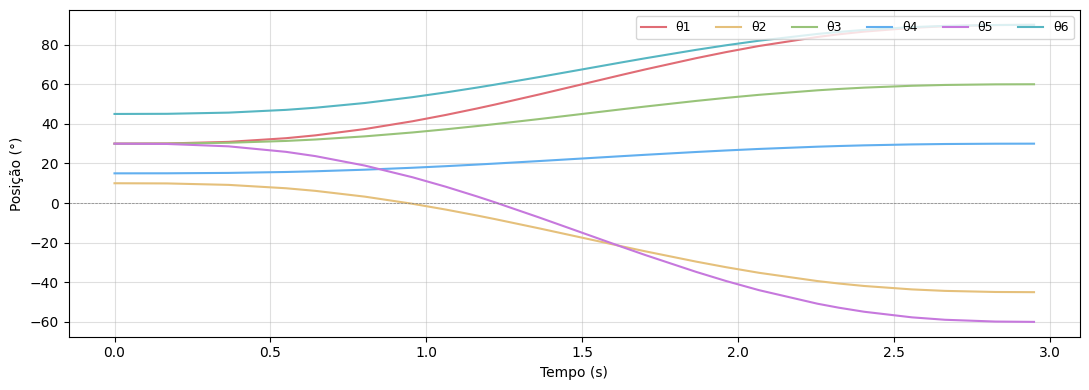

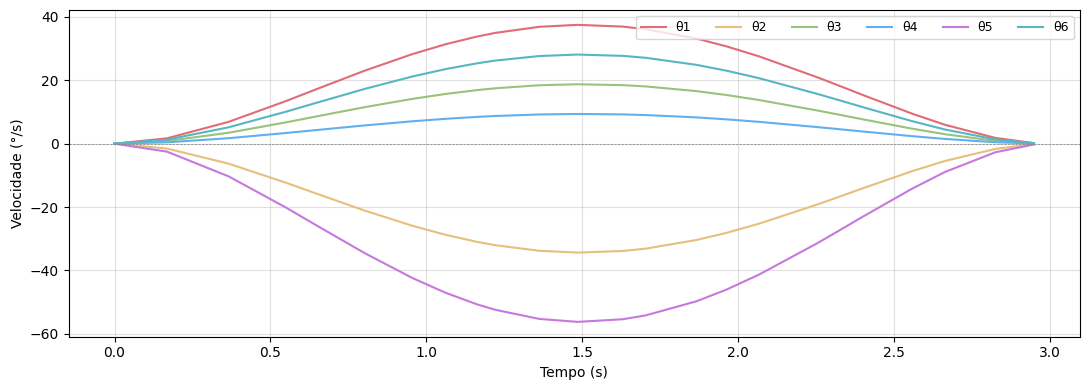

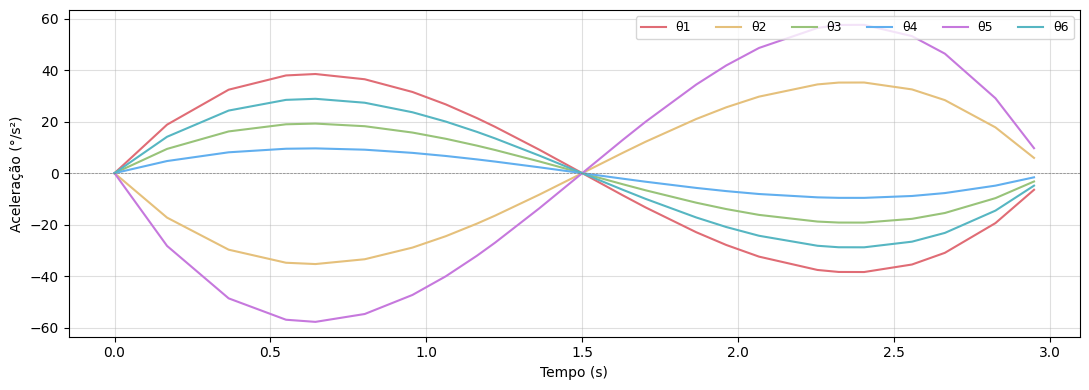

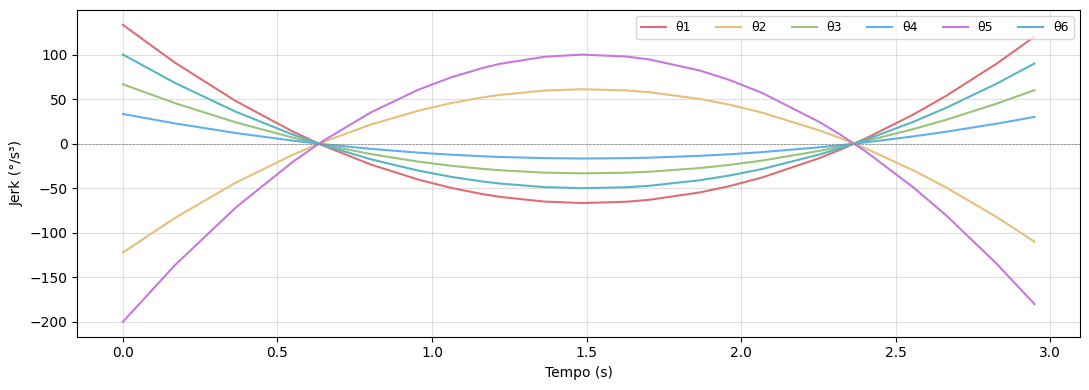

In [27]:
# Pose inicial → Pose final
pose_inicial = [  30,   10,   30,   15,   30,   45]
pose_final = [ 90, -45,  60,  30, -60,  90]

print('Movendo para pose inicial...')
set_joint_positions(pose_inicial)
time.sleep(2.0)

print('\nIniciando trajetória quíntica...')
tf, error, traj, ee_log = polinomio_quinto_grau(pose_final, duration=3)

print(f'\nDuração total       : {tf:.2f} s')
print(f'Erro final por junta: {np.round(error, 3)}')

plot_trajectory(traj['time'], traj['pos'], traj['vel'], traj['acc'], traj['jerk'], pose_final)

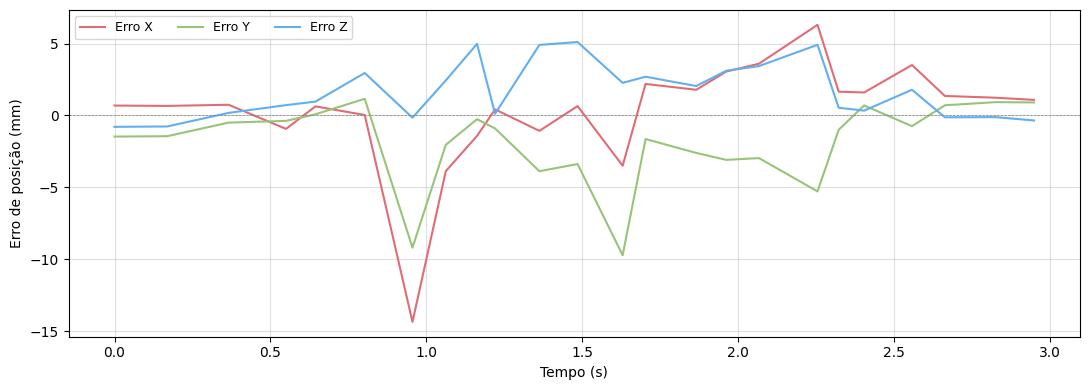

In [ ]:
t = ee_log['time']

pos_ref = np.array(ee_log['pos_ref']) * 1000  # m → mm
pos_sim = np.array(ee_log['pos_sim']) * 1000

labels_xyz = ['X', 'Y', 'Z']
colors_xyz = ['#e06c75', '#98c379', '#61afef']

fig, ax = plt.subplots(figsize=(11, 4))

for i in range(3):
    erro_xyz = pos_sim[:, i] - pos_ref[:, i]
    ax.plot(t, erro_xyz, color=colors_xyz[i],
            lw=1.5, label=f'Erro {labels_xyz[i]}')

ax.axhline(0, color='gray', lw=0.5, ls='--')
ax.set_ylabel('Erro de posição (mm)')
ax.set_xlabel('Tempo (s)')
ax.legend(ncol=3, fontsize=9)
ax.grid(alpha=0.4)

plt.tight_layout()
#plt.savefig('trajetoria_erro_xyz.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 7. Validação — Trajetória no Espaço Cartesiano
Define poses em `[x, y, z]` + `[roll, pitch, yaw]` e move suavemente.


In [ ]:
def build_T06(pos, rpy_deg):
    """Constrói T06 a partir de posição [x,y,z] e RPY em graus (ZYX)."""
    r_, p_, y_ = np.radians(rpy_deg)
    Rz = np.array([[np.cos(y_), -np.sin(y_), 0],
                   [np.sin(y_),  np.cos(y_), 0],
                   [0,           0,          1]])
    Ry = np.array([[ np.cos(p_), 0, np.sin(p_)],
                   [0,           1, 0          ],
                   [-np.sin(p_), 0, np.cos(p_)]])
    Rx = np.array([[1, 0,           0          ],
                   [0, np.cos(r_), -np.sin(r_) ],
                   [0, np.sin(r_),  np.cos(r_) ]])
    T = np.eye(4)
    T[:3,:3] = Rz @ Ry @ Rx
    T[:3, 3] = pos
    return T

def world_rpy_to_base(rpy_world_deg):
    """
    Converte orientação RPY do frame mundo para frame da base (espaço DH).
    """
    # Rotação da base no mundo
    euler_base = sim.getObjectOrientation(base_handle, -1)
    R_base_world = euler_xyz_to_matrix(np.degrees(euler_base))

    # Monta R alvo no mundo
    r_, p_, y_ = np.radians(rpy_world_deg)
    Rz = np.array([[np.cos(y_), -np.sin(y_), 0],
                   [np.sin(y_),  np.cos(y_), 0],
                   [0,           0,          1]])
    Ry = np.array([[ np.cos(p_), 0, np.sin(p_)],
                   [0,           1, 0          ],
                   [-np.sin(p_), 0, np.cos(p_)]])
    Rx = np.array([[1, 0,           0          ],
                   [0, np.cos(r_), -np.sin(r_) ],
                   [0, np.sin(r_),  np.cos(r_) ]])
    R_world = Rz @ Ry @ Rx

    # Converte para frame base
    R_base = R_base_world.T @ R_world
    return rotation_to_rpy(R_base)


def normaliza(a):
    return ((a + 180) % 360) - 180

def move_to_pose(pos, rpy_deg, duration=None,
                 shoulder='auto', elbow='auto', wrist='auto',
                 frame='base'):
    """
    Move o robô suavemente para uma pose cartesiana usando trajetória quíntica.

    Parâmetros
    ----------
    pos      : array [x, y, z] em metros
    rpy_deg  : array [roll, pitch, yaw] em graus (ZYX)
    duration : float  tempo [s] (None = automático)
    shoulder : 'auto' | 'left' | 'right'
    elbow    : 'auto' | 'up'   | 'down'
    wrist    : 'auto' | 'up'   | 'down'
               'auto' → solução mais próxima da configuração atual
    frame    : 'base'  → relativo à base do robô
               'world' → relativo à origem do mundo CoppeliaSim
    """
    pos     = np.array(pos,     dtype=float)
    rpy_deg = np.array(rpy_deg, dtype=float)

    # Converte world → base
    if frame == 'world':
        pos_base_world = sim.getObjectPosition(base_handle, -1) 
        euler_base     = sim.getObjectOrientation(base_handle, -1)
        R_base_world  = euler_xyz_to_matrix(np.degrees(euler_base))

        # Translação + rotação inversa
        pos = R_base_world.T @ (np.array(pos) - np.array(pos_base_world))

        # Orientação
        rpy_deg = world_rpy_to_base(rpy_deg)

        print(f'Base no mundo : {np.round(pos_base_world, 4)}')
        print(f'Pos na base   : {np.round(pos,            4)}')
        print(f'RPY na base   : {np.round(rpy_deg,        2)}')

    # 1) T06 alvo
    T_alvo = build_T06(pos, rpy_deg)

    # 2) IK — todas as soluções
    sols = ik_com_offset(T_alvo)
    if not sols:
        print('Sem solução IK — fora do workspace ou singularidade.')
        return None, None, None

    # 3) Normaliza soluções
    sols_norm = [np.array([normaliza(a) for a in s]) for s in sols]

    config_map = {
        ('left',  'up',   'down'): 0,
        ('left',  'up',   'up'  ): 1,
        ('left',  'down', 'down'): 2,
        ('left',  'down', 'up'  ): 3,
        ('right', 'up',   'down'): 4,
        ('right', 'up',   'up'  ): 5,
        ('right', 'down', 'down'): 6,
        ('right', 'down', 'up'  ): 7,
    }

    use_auto = (shoulder == 'auto' or elbow == 'auto' or wrist == 'auto')

    if use_auto:
        current  = read_joint_positions()
        best_sol = min(sols_norm,
                       key=lambda s: np.linalg.norm(
                           [normaliza(s[j]-current[j]) for j in range(6)]))
        config_str = 'auto'
    else:
        key        = (shoulder, elbow, wrist)
        idx        = config_map.get(key, 0)
        best_sol   = sols_norm[idx] if idx < len(sols_norm) else sols_norm[0]
        config_str = f'shoulder={shoulder} elbow={elbow} wrist={wrist}'

    #print(f'Alvo      : pos={np.round(pos, 3)}  RPY={rpy_deg}°')
    #print(f'Config IK : {config_str}')
    #print(f'Ângulos   : {np.round(best_sol, 2)}')

    # 4) Trajetória quíntica
    tf, error, traj = polinomio_quinto_grau(best_sol, duration=duration)

    # 5) Erro cartesiano final
    pos_obtida, _ = read_ee_pose()
    pos_err = np.linalg.norm(pos_obtida - pos) * 1000
    #print(f'Erro cartesiano final: {pos_err:.2f} mm')

    return tf, error, traj

In [ ]:
# ── Teste ─
set_joint_positions([0,0,0,0,0,0])
time.sleep(2.0)

tf, error, traj = move_to_pose(
    pos     = [0.3, -0.2, 0.8],
    rpy_deg = [180, 0, 90],
    duration = 6.0, elbow='down', shoulder='left', wrist='down',
    frame='world'
)

#plot_trajectory(traj['time'], traj['pos'], traj['vel'], traj['acc'], traj['jerk'], [180, 0, 90])

Base no mundo : [-0.214 -0.314  0.41 ]
Pos na base   : [ 0.114 -0.514  0.39 ]
RPY na base   : [180.  -0.  -0.]
Alvo      : pos=[ 0.114 -0.514  0.39 ]  RPY=[ 1.80000000e+02 -0.00000000e+00 -5.94127614e-12]°
Config IK : shoulder=left elbow=down wrist=down
Ângulos   : [  90.54    4.28   77.96    7.76  -90.   -179.46]
Iniciando trajetória — duração: 6.00s
Iterações   : 191
Erro máximo : 0.008°
Erro médio  : 0.003°
Erro cartesiano final: 1.66 mm


---
## 9. Tarefa — Movimentar um Objeto (Pick)
Sequência de poses para simular pegar e soltar um objeto.


In [11]:
# ── Poses da tarefa ──────────────────────────────────────────────────────────
# Ajuste esses valores para a posição real do objeto na sua cena
cup_handle = sim.getObject('/Cup')
pos_cup    = sim.getObjectPosition(cup_handle, -1)
pos_cup = np.array(pos_cup)


table_handle = sim.getObject('/customizableTable[0]')
pos_table    = sim.getObjectPosition(table_handle, -1)
pos_table    = np.array(pos_table)


# ── Fake grasping ─────────────────────────────────────────────────────────────
connector_handle = sim.getObject('/ROBOTIQ_85_attachPoint')


def grasp():
    sim.setObjectParent(cup_handle, connector_handle, True)

def release():
    sim.setObjectParent(cup_handle, -1, True)


In [18]:
pose_home      = [  0,   0,   0,   0,   0,   0]   # posição inicial
pre_pick_alto = pos_cup + np.array([-0.20, 0,  0])
pos_place_world = np.array([-0.100, 0.242, 0.470])


pose_pick      = pre_pick_alto + np.array([0.18, 0, 0])                  # no objeto
pose_pre_place = [0.4,  0.1, 0.7]                  # acima do destino
orientacao     = [0, 90, 0]                       # EE apontando para baixo

print('=== Iniciando tarefa de pick and place ===\n')

# 1) Home
print('1) Home')
set_joint_positions(pose_home)
time.sleep(2.0)

# 2) Pre-pick
print('2) Pre-pick')
move_to_pose(pos=pre_pick_alto, rpy_deg=orientacao, duration=2.0, frame='world', elbow='down', shoulder='right', wrist='up')

# 3) Pick place 
print('3) Pick')
move_to_pose(pos=pose_pick, rpy_deg=orientacao, duration=2.0, frame='world', elbow='down', shoulder='right', wrist='up')
time.sleep(0.5)  # 
grasp()

# 4) Up 
print("4) Up after pick")
move_pose_pick = pose_pick + np.array([0, 0, 0.2])
move_to_pose(pos=move_pose_pick, rpy_deg=orientacao, duration=2.0, frame='world', elbow='down', shoulder='right', wrist='up')

# 5) Pre-place
print('5) Pre-place')
pose_place_pre_place =  pre_place = pos_place_world + np.array([0, 0, 0.20])                # no destino
move_to_pose(pos=pose_place_pre_place, rpy_deg=orientacao, duration=2.0, frame='world', elbow='up', shoulder='right', wrist='up')

# 6) Place
print('6) Place')
move_to_pose(pos=pos_place_world, rpy_deg=orientacao, duration=2.0, frame='world', elbow='up', shoulder='right', wrist='up')
release()
time.sleep(0.5) 

# 7) Up after place
print('7) Up after place')
pose_after_place = pos_place_world + np.array([-0.1, 0, 0])
move_to_pose(pos=pose_after_place, rpy_deg=orientacao, duration=2.0, frame='world', elbow='up', shoulder='right', wrist='up')
time.sleep(0.5)

# 8) Home
print('8) Retorna ao Home')

polinomio_quinto_grau(pose_home, duration=3)
print('\n=== Tarefa concluída ===')


=== Iniciando tarefa de pick and place ===

1) Home
2) Pre-pick
Base no mundo : [-0.214 -0.314  0.41 ]
Pos na base   : [-0.044  -0.414   0.0617]
RPY na base   : [90. 90.  0.]
Alvo      : pos=[-0.044 -0.414  0.062]  RPY=[90. 90.  0.]°
Config IK : shoulder=right elbow=down wrist=up
Ângulos   : [ -73.68   -6.65 -148.17  -25.18  -73.68  -90.  ]
Iniciando trajetória — duração: 2.00s
Iterações   : 81
Erro máximo : 0.008°
Erro médio  : 0.005°
Erro cartesiano final: 1.27 mm
3) Pick
Base no mundo : [-0.214 -0.314  0.41 ]
Pos na base   : [-0.044  -0.594   0.0617]
RPY na base   : [90. 90.  0.]
Alvo      : pos=[-0.044 -0.594  0.062]  RPY=[90. 90.  0.]°
Config IK : shoulder=right elbow=down wrist=up
Ângulos   : [ -80.96  -24.71 -119.69  -35.6   -80.96  -90.  ]
Iniciando trajetória — duração: 2.00s
Iterações   : 77
Erro máximo : 0.008°
Erro médio  : 0.003°
Erro cartesiano final: 1.55 mm
4) Up after pick
Base no mundo : [-0.214 -0.314  0.41 ]
Pos na base   : [-0.044  -0.594   0.2617]
RPY na base   : 

In [ ]:
# ── Pick and place ────────────────────────────────────────────────────────────
pos_cup    = sim.getObjectPosition(cup_handle, -1)

pos_cup   = np.array(pos_cup)
orientacao = [0, -90, 0]   # EE apontando para baixo

pre_pick  = pos_cup + np.array([0, 0,  0.20])
pick      = pos_cup + np.array([0, 0,  0.05])
pre_place = pos_cup + np.array([0.4, 0, 0.20])
place     = pos_cup + np.array([0.4, 0, 0.05])

print('=== Pick and Place ===\n')

print('1) Home')
set_joint_positions([0,0,0,0,0,0])
time.sleep(2.0)

print('2) Pre-pick')
move_to_pose(pre_pick, orientacao, frame='world', duration=3.0)

print('3) Pick')
move_to_pose(pick, orientacao, frame='world', duration=2.0)
grasp()

print('4) Sobe')
move_to_pose(pre_pick, orientacao, frame='world', duration=2.0)

print('5) Pre-place')
move_to_pose(pre_place, orientacao, frame='world', duration=3.0)

print('6) Place')
move_to_pose(place, orientacao, frame='world', duration=2.0)
release()

print('7) Home')
set_joint_positions([0,0,0,0,0,0])
time.sleep(2.0)

print('\n=== Concluído ===')

=== Pick and Place ===

1) Home
2) Pre-pick
Base no mundo : [-0.214 -0.314  0.41 ]
Pos na base   : [-0.044  -0.614   0.2617]
RPY na base   : [-90. -90.   0.]
Alvo      : pos=[-0.044 -0.614  0.262]  RPY=[-90. -90.   0.]°
Config IK : auto
Ângulos   : [-85.26 -99.23  31.08  68.15 -94.74 -90.  ]
Iniciando trajetória — duração: 3.00s
Iterações   : 126
Erro máximo : 0.014°
Erro médio  : 0.003°
Erro cartesiano final: 1.06 mm
3) Pick
Base no mundo : [-0.214 -0.314  0.41 ]
Pos na base   : [-0.044  -0.614   0.1117]
RPY na base   : [-90. -90.   0.]
Alvo      : pos=[-0.044 -0.614  0.112]  RPY=[-90. -90.   0.]°
Config IK : auto
Ângulos   : [ -85.26 -110.3    31.36   78.94  -94.74  -90.  ]
Iniciando trajetória — duração: 2.00s
Iterações   : 83
Erro máximo : 10.211°
Erro médio  : 1.706°
Erro cartesiano final: 108.58 mm
  Objeto anexado ✅
4) Sobe
Base no mundo : [-0.214 -0.314  0.41 ]
Pos na base   : [-0.044  -0.614   0.2617]
RPY na base   : [-90. -90.   0.]
Alvo      : pos=[-0.044 -0.614  0.262]  RPY